<a href="https://colab.research.google.com/github/DawiSyauqi/DIF60202_IP_2311532009/blob/main/Tugas_Convolution_Muhammad_Dawi_Syauqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Konvolusi selesai! Citra hasil disimpan di: citra_output_smoothed.jpg


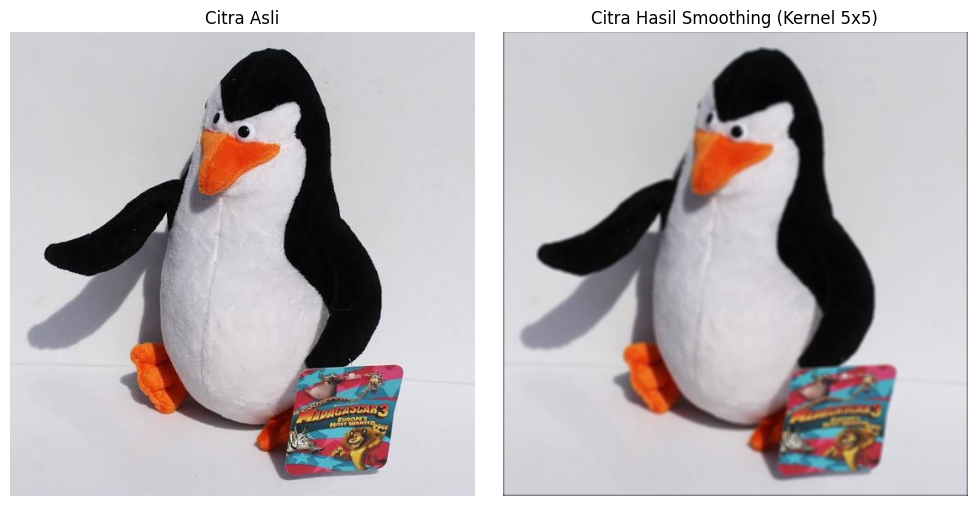

In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def konvolusi_manual(image_path, output_path):
    # 1. Membaca citra
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img, dtype=np.float32)

    tinggi, lebar, kanal = img_array.shape

    # 2. Membuat Kernel Rataan 5x5
    # Sesuai contoh di slide: K = 1/25 * [matriks 5x5 berisi angka 1]
    kernel_size = 5
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / 25.0

    # 3. Menyiapkan citra output dan padding
    # Karena kernel 5x5, kita butuh padding sebanyak (5-1)/2 = 2 piksel di setiap sisi
    pad_size = kernel_size // 2

    # Menambahkan zero-padding pada citra
    img_padded = np.pad(img_array, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='constant', constant_values=0)

    # Matriks kosong untuk hasil
    img_result = np.zeros_like(img_array)

    # 4. Proses Konvolusi
    # Mengiterasi setiap piksel (i, j) pada citra asli
    for i in range(tinggi):
        for j in range(lebar):
            # Konvolusi dilakukan pada setiap kanal warna R, G, B secara terpisah
            for c in range(kanal):
                # Mengambil region 5x5 dari citra yang sudah di-pad
                region = img_padded[i:i+kernel_size, j:j+kernel_size, c]

                # Mengalikan region dengan kernel dan menjumlahkannya (linear combination)
                hasil_piksel = np.sum(region * kernel)

                # Menyimpan hasil ke matriks output
                img_result[i, j, c] = hasil_piksel

    # Memastikan nilai piksel berada dalam rentang valid 0-255
    img_result = np.clip(img_result, 0, 255).astype(np.uint8)

    # 5. Menyimpan hasil ke direktori
    output_img = Image.fromarray(img_result)
    output_img.save(output_path)
    print(f"Konvolusi selesai! Citra hasil disimpan di: {output_path}")

    # 6. Visualisasi Hasil
    plt.figure(figsize=(10, 5))

    # Menampilkan Citra Asli
    plt.subplot(1, 2, 1)
    plt.title("Citra Asli")
    plt.imshow(img)
    plt.axis('off')

    # Menampilkan Citra Hasil Konvolusi
    plt.subplot(1, 2, 2)
    plt.title("Citra Hasil Smoothing (Kernel 5x5)")
    plt.imshow(img_result)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Cara Menjalankan ---
# Ganti '/content/images (1).jpeg' dengan lokasi file gambar Anda
input_gambar = '/content/images (1).jpeg'
output_gambar = 'citra_output_smoothed.jpg'

konvolusi_manual(input_gambar, output_gambar)